#### 파이프라인 ?
```
데이터 전처리, 특성 추출 모델학습을 하나의 흐름으로 연결
```
#### 사용이유
```
코드 간결화 :
재현성 보장 :
데이터 누수 방지 :
하이퍼 파라미터 뉴팅 용이 :
```
#### 파이프라인 구성요소
```
변환기
    데이터를 변환하는 객체
    fit() : 데이터에서 파라미터를 학습 ^ 파라미터
    transform() : 학습파라미터로 데이토를 변환
    StandardScaler PCA MinMaxScaler ...
추정기
```
    머신러닝 모델
    fit() : 데이터로 모델을 학습
    predict() : 예측 수행
    RandomForest SVM ...
```
#### 데이터 : 위스콘시 유방암 데이터 - 대표적인 이진 분류 데이터
```
클래스 2(약성 악성)
특성 : 10개
특성 :  10개
| 그룹 | Feature 이름          | 의미                                |
| -- | ------------------- | --------------------------------- |
| 1  | `radius`            | 세포 핵의 반지름 평균 (centroid와 경계 사이 거리) |
| 2  | `texture`           | 회색조 값의 표준편차 (질감)                  |
| 3  | `perimeter`         | 세포 핵의 둘레 길이                       |
| 4  | `area`              | 세포 핵의 면적                          |
| 5  | `smoothness`        | 반지름의 국소적 변화 (핵 경계의 매끄러움)          |
| 6  | `compactness`       | 둘레² / 면적 - 1.0 (핵의 조밀도)           |
| 7  | `concavity`         | 오목한 부분의 심도 (함몰 정도)                |
| 8  | `concave points`    | 오목한 부분의 개수                        |
| 9  | `symmetry`          | 대칭성                               |
| 10 | `fractal_dimension` | 경계의 복잡도 (프랙탈 차원 근사값)              |
결측값이 없는 데이터
```

In [89]:
# 파이프 라인 구성
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression # ^

pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('pca',PCA(n_components=2)),
    ('claaifier',LogisticRegression())
])

#### 파이프라인 실행과정
```
위에서 아래로 작동한다.
파이프라인은 위에서 아래로 순서대로 실행된다.
fit 시에는 앞 단계가 다음 단계의 입력으로 전달된다.
마지막 단계만 모델(예: 분류, 회귀) 여야 한다.

->
```

#### 데이터 누수 방지
```
잘못된 예
전체 데이터를 먼저 스케일링
x_scaled = scaler.fit_transform(x)
x_train, x_test = train_test_split(x_scaled)
model.fit(x_train, y_train)

문제 : 전체 데이터를 먼저 스케일링 -> 학습 데이터만 스케일링을 해야한다. 테스트 정보데이터는 스케일에 사용되면 안된다.
^ 근데 이러면 훈련과 테스트의 데이터 규격차이가 나서 모델 성능이 뒤죽박죽으로 나오는 거아닌가?

올바른 예
학습데이터만으로 스케일링
x_train, x_test = train_test_split(x)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)  # fit없이 transform만 !!!
model.fit(x_train_scaled, y_train)
```

#### 파이프라인 사용(best)
```
pipe.fit(x_train,y_train) # 학습 데이터만 fit
pipe.predict(x_test) # 테스트 데이터는 transform만
```

#### 교차검증 k-겹
```
홀드아웃 : 데이터를 학습세트 테스트 세트 한번만 분할한다
전체데이터 100%
    학습 70~80
    테스트 20~30
장점 :
    빠르다
    대용량 데이터에 적합하다
단점 :
    데이터 분할에 따라서, 성능이 크게 달라질 수 있다
    작은 데이터 셋에선 불안정하다
    일부 데이터만 학습에 사용한다
언제 사용 :
    데이터가 충분히 많을 때(수만개 이상)
    빠르게 평가할때
```
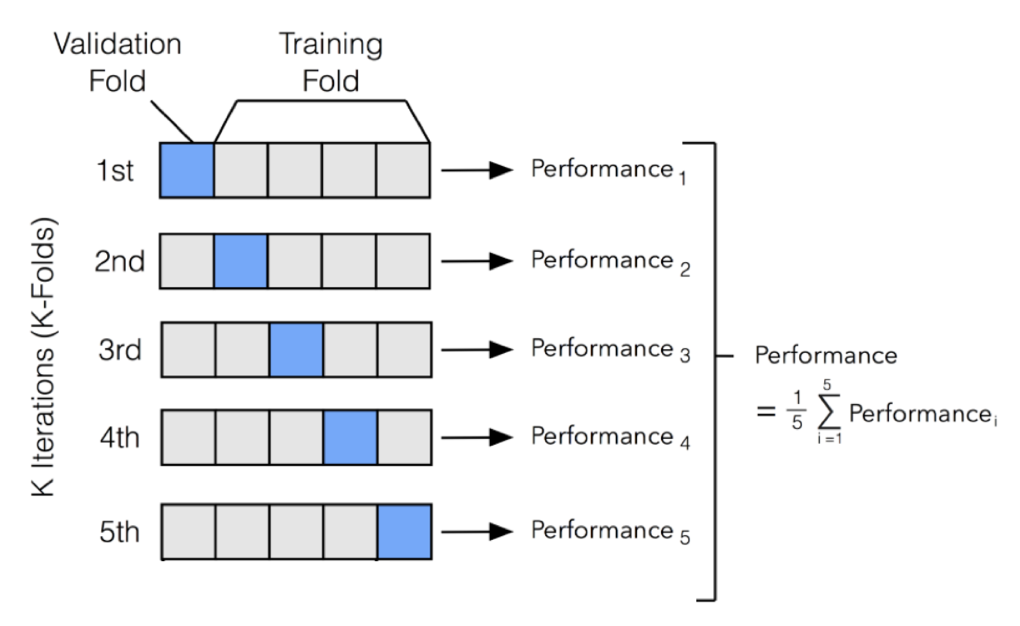

#### k-fold
```
일반 k-fold
층화 Stratified k-fod #^
```
상세히 들어가지말고 일단 넘기기 - 그리 깊게 언급 안하심 훑어가며 크게크게 개념 잡는 걸 우선으로

#### 학습곡선과 검증곡선
```
모델성능을 시각화
```
학습데이터 크기에 따른 모델성능을 시각화 였는데,
아마 데이터 크기에 따라 변화하는 모델성능을 확인해보라는 표현같네

#### 그리드 서치를 사용하여 머신러닝 모델 세부 튜닝
```
하이퍼파라메터 :
    파라메터: 학습으로 찾음
        선형회귀 계수, 신경망의 가중치 ...

    하이퍼 파라메터 : 사람이 설정
        학습률, 정규화, 트리의 깊이 ...

하리퍼파라미터 모색 방법 :
    그리드 서치 : 모든 가능한 조합으로 체계적으로 시도
    랜덤그리드 서치 : 모든 가능한 조합을 랜덤
        더 넓은 영역을 탐색 -> 더 넓은 영역 : 파라미터의 조합의 경우의 수가 많을 때
언제 사용 :
    그리드 서치 : 하이퍼 파라미터 : 2~3개
    랜덤서치 : 하이퍼 파라미터 : 4개 이상
하이퍼 파라미터 비교 예제 :
    하이퍼파라미터 갯수 3개
    그리드 서치 : 27번 3**3
    랜덤서치 : n_iter=10 로 횟수 설정, 여기선 10번
```

In [90]:
# 필요한 라이브러리
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,cross_val_score,StratifiedKFold,learning_curve,
    validation_curve,GridSearchCV,RandomizedSearchCV,cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline,make_pipeline
from scipy.stats import randint, uniform #^
import warnings #^
warnings.filterwarnings('ignore') #^
import pandas as pd

In [91]:
# section 1 : 위스콘신 유방암 데이터 로드 및 탐색
'''
    데이터 셋 구조 이해
    
'''
print('section 1: 유방암 데이터셋')

# 데이터 로드
data = load_breast_cancer()
X,y = data.data, data.target
print('데이터셋')
print(f'샘플 수 :{X.shape[0]}')
print(f'특성 수 :{X.shape[1]}')
print(f'클래스 수 :{data.target_names}')

# 클래스 분포
unique,counts = np.unique(y,return_counts=True)
print('클래스 분포')
for label,count in zip(unique,counts):
    class_name = data.target_names[label]
    percentage = count / len(y) *100
print(f' {class_name} : {count}개 ({percentage:.1f}%)')

# 특성 통계 (처음 5개 특성)
print("특성 통계 (처음 5개 특성)")
for i in range(5):
    print(f'{data.feature_names[i]}')
    print(f'평균 : {X[:,i].mean():.2f}')
    print(f'표준편차 : {X[:,i].std():.2f}')
    print(f'최소값 : {X[:,i].min():.2f}')
    print(f'최대값 : {X[:,i].max():.2f}')

section 1: 유방암 데이터셋
데이터셋
샘플 수 :569
특성 수 :30
클래스 수 :['malignant' 'benign']
클래스 분포
 benign : 357개 (62.7%)
특성 통계 (처음 5개 특성)
mean radius
평균 : 14.13
표준편차 : 3.52
최소값 : 6.98
최대값 : 28.11
mean texture
평균 : 19.29
표준편차 : 4.30
최소값 : 9.71
최대값 : 39.28
mean perimeter
평균 : 91.97
표준편차 : 24.28
최소값 : 43.79
최대값 : 188.50
mean area
평균 : 654.89
표준편차 : 351.60
최소값 : 143.50
최대값 : 2501.00
mean smoothness
평균 : 0.10
표준편차 : 0.01
최소값 : 0.05
최대값 : 0.16


In [92]:
# 학생풀이
# 특성 통계 (처음 5개 특성) 데이터 프레임으로 전환
# 열 이름 리스트
columns = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
           'mean smoothness']

# 행 이름 리스트
index = ['mean', 'std', 'max', 'min']

# 4x5 빈 DataFrame 생성
df = pd.DataFrame(np.nan, index=index, columns=columns)

# 안에 넣을 값 만들기
list_mean = []
list_std = []
list_max = []
list_min = []
for i in range(5):
    list_mean.append(X[:,i].mean())
    list_std.append(X[:,i].std())
    list_max.append(X[:,i].max())
    list_min.append(X[:,i].min())

# 각 행에 리스트 추가
df.loc['mean'] = list_mean
df.loc['std']  = list_std
df.loc['max']  = list_max
df.loc['min']  = list_min

df = df.round(2)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.28,351.60,0.01
max,28.11,39.28,188.50,2501.00,0.16
min,6.98,9.71,43.79,143.50,0.05


In [93]:
# 강사풀이
# Section 1  : 위스콘신 유방망 데이터셋 로드 및 탐색
def section1_load_data():
    """
        데이터셋 구조 이해
        특성과 타겟의 관계 파악
        클래스 분포 확인
    """
    print("section 1 : 위스콘신 유방암 데이터셋")

    # 데이터 로드
    data = load_breast_cancer()
    X, y = data.data, data.target
    print("데이터셋 기본정보")
    print(f'샘플 수 : { X.shape[0] }')
    print(f'특성 수 : { X.shape[1] }')
    print(f'클래스 : {data.target_names}')
    # 클래스 분포
    unique, counts =  np.unique(y,return_counts=True)
    print("클래스분포")
    for label, count in zip(unique, counts):
        class_name = data.target_names[label]
        percentage = count / len(y) * 100
        print(f' {class_name} : {count}개 ({percentage:.1f}%)')
    # 특성 통계
    print("특성 통계 (처음 5개 특성)")
    df_lists = []
    for i in range(5):
        index_name = data.feature_names[i]
        stats = {
                'mean': X[:,i].mean(),
                    'std':X[:,i].std(),
                    'min':X[:,i].min(),
                    'max':X[:,i].max()
        }    
        df_lists.append(pd.DataFrame(stats,index = [index_name]))
    print(pd.concat(df_lists))
    return X, y, data

In [94]:
X,y,data = section1_load_data()

section 1 : 위스콘신 유방암 데이터셋
데이터셋 기본정보
샘플 수 : 569
특성 수 : 30
클래스 : ['malignant' 'benign']
클래스분포
 malignant : 212개 (37.3%)
 benign : 357개 (62.7%)
특성 통계 (처음 5개 특성)
                       mean         std        min        max
mean radius       14.127292    3.520951    6.98100    28.1100
mean texture      19.289649    4.297255    9.71000    39.2800
mean perimeter    91.969033   24.277619   43.79000   188.5000
mean area        654.889104  351.604754  143.50000  2501.0000
mean smoothness    0.096360    0.014052    0.05263     0.1634


In [95]:
section1_load_data()

section 1 : 위스콘신 유방암 데이터셋
데이터셋 기본정보
샘플 수 : 569
특성 수 : 30
클래스 : ['malignant' 'benign']
클래스분포
 malignant : 212개 (37.3%)
 benign : 357개 (62.7%)
특성 통계 (처음 5개 특성)
                       mean         std        min        max
mean radius       14.127292    3.520951    6.98100    28.1100
mean texture      19.289649    4.297255    9.71000    39.2800
mean perimeter    91.969033   24.277619   43.79000   188.5000
mean area        654.889104  351.604754  143.50000  2501.0000
mean smoothness    0.096360    0.014052    0.05263     0.1634


(array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [96]:
# Section 2 : 파이프라인 기본 사용법
def section2_basic_pipeline(X, y):
    """
    - Pipeline 객체생성
    - 표준화 + 모델 학습을 한번에 수행
    - 파이프라인의 장점을 이해
    """
    # 데이터 분할
    X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    # 수동방식
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    manual_score =  lr.score(X_test_scaled ,y_test )
    print(f'학습세트 크기 : {X_train.shape[0]}')
    print(f'테스트세트 크기 : {X_test.shape[0]}')
    print(f'테스트 정확도 : { manual_score:.4f}' )
    
    print('파이프라인 ', '*'*100)
    pipe = Pipeline([
        ('scaler',StandardScaler() ),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])
    pipe.fit( X_train , y_train )
    pipeline_score = pipe.score( X_test, y_test )
    print(f'파이프라이 구조')
    for name,step in  pipe.steps:
        print(f' {name} : {step.__class__.__name__} ')
    
    print(f"테스트 정확도 : {pipeline_score:.4f}")
    print(f' 수동방식과 동일한 결과 : {np.isclose(manual_score, pipeline_score)}')

In [97]:
section2_basic_pipeline(X,y)

학습세트 크기 : 398
테스트세트 크기 : 171
테스트 정확도 : 0.9883
파이프라인  ****************************************************************************************************
파이프라이 구조
 scaler : StandardScaler 
 classifier : LogisticRegression 
테스트 정확도 : 0.9883
 수동방식과 동일한 결과 : True


In [98]:
# Section 3 : 교차 검증 비교(홀드아웃 vs k-겹)
def section3_cross_validation(X, y):
    """
    - 홀드아웃의 한계
    - k-겹 교차검증의 장점
    - 층화 k-겹의 중요성
    """
    pipe = Pipeline([
        ('scaler',  StandardScaler() ),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000) )
    ])
    # 1) 여러번 반복해서 불안정성 확인
    holdout_scores = []
    for i in range(10):
        X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=i) # stratify=y 는 제외 ^
        pipe.fit(X_train,y_train)
        holdout_score = pipe.score(X_test, y_test)
        holdout_scores.append(holdout_score)
        # 처음 3개만 출력
        if i <3:
            print(f'  {i+1} : {holdout_score:.4f}')
    print('---')
    print(f'홀드아웃 평균 : {np.mean(holdout_scores):.4f}  표준편차 : {np.std(holdout_scores):.4f}')
    print(f'min : {np.min(holdout_scores)}   max : {np.max(holdout_scores)}')

    # 2) 5-겹 교차 검증
    cv_scores = cross_val_score(pipe,X,y,cv=5,scoring='accuracy')
    print('각 Fold의 점수')
    for i, score in enumerate(cv_scores,1):
        print(f' fold {i} : {score:.4f}')
    print(f'교차검증 평균 : {np.mean(cv_scores):.4f}  표준편차 : {np.std(cv_scores):.4f}')

    print('-'*100)
    # 3) 층화 k 겹
    skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
    stratified_scores = cross_val_score(pipe,X,y,cv=skf,scoring='accuracy')
    print('각 Fold의 점수')
    for i, score in enumerate(stratified_scores,1):
        print(f' fold {i} : {score:.4f}')
    print(f'층화 교차검증 평균 : {np.mean(stratified_scores):.4f}  표준편차 : {np.std(stratified_scores):.4f}')

    # 각 fold의 클래스 분포 확인
    for i, (train_index, test_index) in enumerate(skf.split(X,y),1):
        y_fold =  y[test_index]
        unique,counts =  np.unique(y_fold, return_counts =True)
        ratio = counts[1] / len(y_fold) * 100
        print(f' fold {i} : 악성 {ratio:.1f}%')

In [99]:
section3_cross_validation(X,y)

  1 : 0.9766
  2 : 0.9708
  3 : 0.9708


---
홀드아웃 평균 : 0.9766  표준편차 : 0.0074
min : 0.9649122807017544   max : 0.9883040935672515
각 Fold의 점수
 fold 1 : 0.9825
 fold 2 : 0.9825
 fold 3 : 0.9737
 fold 4 : 0.9737
 fold 5 : 0.9912
교차검증 평균 : 0.9807  표준편차 : 0.0065
----------------------------------------------------------------------------------------------------
각 Fold의 점수
 fold 1 : 0.9737
 fold 2 : 0.9474
 fold 3 : 0.9649
 fold 4 : 0.9912
 fold 5 : 0.9912
층화 교차검증 평균 : 0.9737  표준편차 : 0.0166
 fold 1 : 악성 62.3%
 fold 2 : 악성 62.3%
 fold 3 : 악성 63.2%
 fold 4 : 악성 63.2%
 fold 5 : 악성 62.8%


```
1️⃣ 홀드아웃(Hold-out)
개념: 데이터를 한 번만 나눠서 학습(train)과 검증(validation) 또는 테스트(test) 세트로 분리하는 방법 : train_test_split
방법: 예를 들어 데이터 100개 → 80개 학습, 20개 검증
장점: 간단하고 빠름
단점: 데이터 분할에 따라 성능이 달라질 수 있음 → 결과가 불안정, 표준편차가 크게난다

2️⃣ K-겹 교차검증(K-Fold Cross Validation)
개념: 데이터를 K개의 동일한 크기 조각으로 나누고, 그 중 하나를 검증 세트로, 나머지 K-1개를 학습 세트로 사용하여 K번 반복
방법:
데이터를 K개 조각으로 나눈다
i번째 조각을 검증, 나머지를 학습 → 모델 학습/평가
i = 1~K까지 반복 후 평균 성능 계산
장점: 데이터 활용 효율 높음, 성능 평가 안정적
단점: 계산 비용 증가

3️⃣ 층화 K-겹 교차검증(Stratified K-Fold)
개념: K-겹 교차검증을 클래스 비율을 유지하면서 수행
왜 필요한가: 클래스 불균형(예: 긍정 90%, 부정 10%)이 있을 때 단순 K-겹은 각 fold마다 클래스 비율이 달라질 수 있음 → 평가가 편향될 수 있음
방법: 각 fold가 원래 데이터의 클래스 비율과 거의 동일하게 샘플링
장점: 분류 문제에서 성능 평가가 더 신뢰성 있음
```

In [100]:
# Section 4 : 학습곡선으로 편향-분산 분석
def section4_learning_curves(X,y):
    """
    - 학습곡선
    - 과소적합 / 과대적합 판단
    - 데이터 추가 필요성 판단
    """
    print('다양한 모델의 학습곡선 비교')
    models = [
        ('과소적합 예시\n(단순 모델)', 
         Pipeline([('sacler',StandardScaler()),('clf',LogisticRegression(C=0.01,max_iter = 1000))]) ),
         # C ^
        # 규제란 모델이 너무 복잡해져서 훈련 데이터에만 잘 맞고,
        # 새로운 데이터에는 성능이 떨어지는 과적합(overfitting)을 방지하기 위해 사용된다.
        # C는 규제 강도의 역수
        # C가 작으면 → 규제가 강해짐 → 가중치(w)가 작아지고 모델이 단순해짐
        # C가 크면 → 규제가 약해짐 → 모델이 데이터에 더 잘 맞게 학습됨
        ('적절한 적합 예시\n(기본 모델)', 
         Pipeline([('sacler',StandardScaler()),('clf',LogisticRegression(C=1.0,max_iter = 1000))]) ),

        ('약간 과대 적합 예시\n(복잡 모델)', 
         Pipeline([('sacler',StandardScaler()),('clf',SVC(kernel='rbf',gamma='auto'))]) ),

        ('과대적합 예시\n(매우복잡)', # 과대적합이 일어나기 쉬운모델로 선정 : 과대적합을 확인하기 위함
         Pipeline([('sacler',StandardScaler()),('clf',DecisionTreeClassifier())]) ),
    ]

    # 한글 폰트 오류 문제 해결
    from matplotlib import font_manager, rc
    font_path = "C:\\Windows\\Fonts\\malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    print(font_name) # Malgun Gothic
    rc('font', family=font_name)

    fig, axes = plt.subplots(2,2,figsize=(15,12))

    for idx, (title, model) in enumerate(models):
        ax = axes[idx // 2, idx % 2] # (0, 0) (0, 1) (1, 0) (1, 1)
        # 학습곡선 계산
        train_sizes,train_score,test_score =          learning_curve(
            model,X,y,cv=5,
            train_sizes=np.linspace(0.1,1.0,10),
            scoring='accuracy',
            n_jobs=-1
        )
        # 평균과 표준편차
        train_mean = train_score.mean(axis=1)
        train_std =  train_score.std(axis=1)
        test_mean = test_score.mean(axis=1)
        test_std = test_score.std(axis=1)

        # 그래프 그리기
        ax.plot(train_sizes,train_mean, label='train score', marker='o', color='blue')
        ax.fill_between(train_sizes, train_mean - train_std, train_mean+train_std, alpha=0.15, color='blue')

        ax.plot(train_sizes,test_mean, label='test score', marker='s', color='red')
        ax.fill_between(train_sizes, test_mean - test_std, test_mean+test_std, alpha=0.15, color='red')

        ax.set_xlabel('train sample counts', fontsize=10)
        ax.set_ylabel('accuracy', fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.5,1.05])
        
        # 최종성능 출력
        final_train = train_mean[-1]
        final_test = test_mean[-1]
        gap = final_train - final_test

        print(f' 최종 학습점수 : {final_train}')
        print(f' 최종 검증점수 : {final_test}')
        print(f' 점수차이 : {gap}')

        if gap < 0.05 and final_test < 0.85: # final_test 왜 0.85을 기준으로 세웠는지
            print(' 진단 : 과소적합(높은 편향)')
            print(' 해결책 : 더 복잡한 모델 사용')
        elif gap > 0.15: # ^
            print(' 진단 : 과대적합(높은 분산)')
            print(' 해결책 : 더 많은 데이터 수집 또는 정규화 증가')
        else:
            print(' 진단 : 적절한 적합')

다양한 모델의 학습곡선 비교
Malgun Gothic
 최종 학습점수 : 0.9556043956043956
 최종 검증점수 : 0.9490607048594939
 점수차이 : 0.006543690744901687
 진단 : 적절한 적합
 최종 학습점수 : 0.9894505494505494
 최종 검증점수 : 0.9806862288464524
 점수차이 : 0.008764320604097042
 진단 : 적절한 적합
 최종 학습점수 : 0.9872527472527473
 최종 검증점수 : 0.9736376339077782
 점수차이 : 0.01361511334496901
 진단 : 적절한 적합
 최종 학습점수 : 1.0
 최종 검증점수 : 0.924406148113647
 점수차이 : 0.07559385188635304
 진단 : 적절한 적합


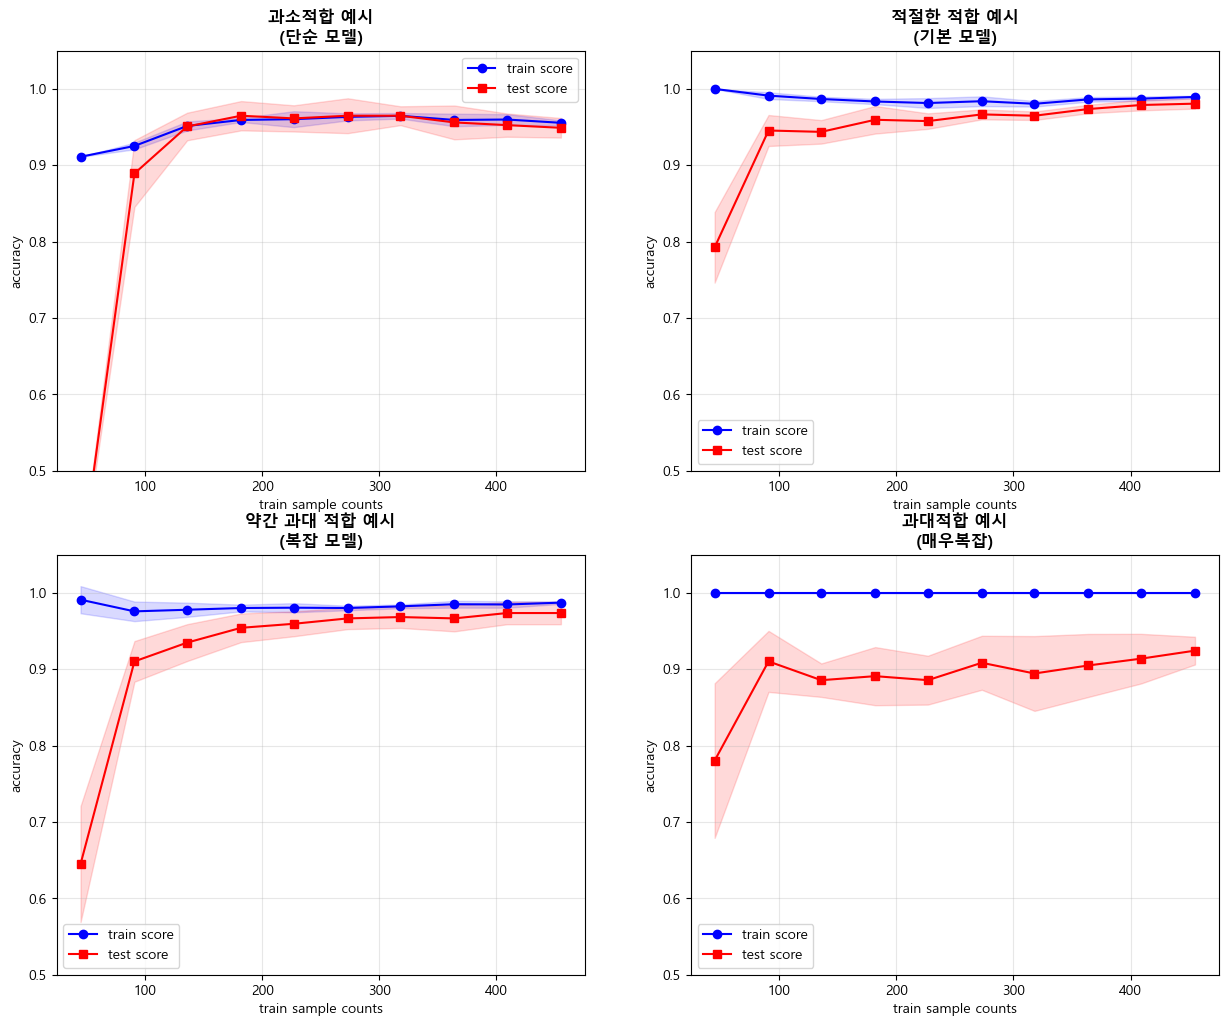

In [101]:
section4_learning_curves(X,y)

In [102]:
# 2번 best 케이스, 3번 그다음 best 케이스
# 최종 학습점수와 최종 검증점수의 차인 gap이  0.05 를 기준으로, 

```
학습곡선 분석 단계
1. 훈련 점수와 검증 점수 비교
두 곡선이 너무 가깝게 낮게 위치 → 과소적합
두 곡선이 높고 거의 겹침 → 적절한 학습
푸른선(훈련) 높고 빨간선(검증) 낮음 → 과대적합

2. 학습 데이터 양에 따른 변화 관찰 ^
데이터가 늘어나도 검증 점수가 계속 낮으면 모델이 단순 → 과소적합
데이터가 늘어나면서 검증 점수가 천천히 올라가면 → 더 많은 데이터 필요
데이터가 늘어나도 검증 점수가 거의 변화 없으면 → 더 복잡한 모델 필요 가능

3. 표준편차(음영) 확인
표준편차가 크면 모델이 불안정 → 데이터가 적거나 모델이 민감함
표준편차가 작으면 안정적 → 모델이 학습 안정
표준편차가 뭐길래? ^
```

In [ ]:
# 검증곡선으로 하이퍼 파라메터 분석
# 파이프라인을 이용해서 검증곡선의 하이퍼파라미터를 찾기
def section5_validation_curve(X, y):
    """
    - 검증곡선
    - 최적 화이퍼파라메터 범위 확인
    - 과대/과소 적합 구간 확인
    """
    fig, ax = plt.subplots(1,2, figsize=(15,5))
    # Logistic Regression C 파라메터
    print(f'Logistic Regression 정규화 파라메터 C')
    print(f' ( C 가 적을수록 강한 정규화 )')

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    param_range = np.logspace(-4,4,9)  # 0.0001 ~ 10000
        # np.logspace()^
            # np.logspace는 지수적으로 균등한 숫자 시퀀스를 만들어주는 함수예요.
            # 즉, 선형적으로 증가하는 게 아니라 로그 스케일(지수)로 증가하는 숫자들을 만드는 것.
            # 1 10 100 1000 이런식
            # start : 시작 지수
            # stop : 끝 지수
            # num : 생성할 숫자의 개수 (default=50)
            # base : 밑(base, default=10)
    train_scores, test_scores =  validation_curve(
        pipe,X,y,
        param_name='clf__C',
        param_range= param_range,
        cv=5,
        scoring='accuracy'  ,
        n_jobs = -1
    )
 # 평균과 표준편차
    train_mean = train_scores.mean(axis=1)
    train_std =  train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    # 그래프 그리기  semilogx x축을 로그 스케일로 설정해서 선 을 그리는 함수  작은값부터 큰 값까지 폭 넒게 분포된 값을 시각화
    ax[0].semilogx(param_range,train_mean, label='train score', marker='o', color='blue')
    ax[0].fill_between(param_range, train_mean - train_std, train_mean+train_std, alpha=0.15, color='blue')

    ax[0].semilogx(param_range,test_mean, label='test score', marker='s', color='red')
    ax[0].fill_between(param_range, test_mean - test_std, test_mean+test_std, alpha=0.15, color='red')

    ax[0].set_xlabel('Parameter C', fontsize=10)
    ax[0].set_ylabel('accuracy', fontsize=10)
    ax[0].set_title("logistic regression C ", fontsize=12, fontweight='bold')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)  

    # 최적의 값
    best_idx = np.argmax(test_mean)  
    best_c = param_range[best_idx]
    best_score = test_mean[best_idx]

    print(f'최적의 C : {best_c:.4f}')
    print(f'최고 검증 점수는 : {best_score:.4f}')

    # Decision Tree max_depth 파라메터

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier())
    ])
    param_range = range(1,21)
    train_scores, test_scores =  validation_curve(
        pipe,X,y,
        param_name='clf__max_depth',
        param_range= param_range,
        cv=5,
        scoring='accuracy'  ,
        n_jobs = -1
    )
    # 평균과 표준편차
    train_mean = train_scores.mean(axis=1)
    train_std =  train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    # 그래프 그리기  semilogx x축을 로그 스케일로 설정해서 선 을 그리는 함수  작은값부터 큰 값까지 폭 넒게 분포된 값을 시각화
    ax[1].semilogx(param_range,train_mean, label='train score', marker='o', color='blue')
    ax[1].fill_between(param_range, train_mean - train_std, train_mean+train_std, alpha=0.15, color='blue')

    ax[1].semilogx(param_range,test_mean, label='test score', marker='s', color='red')
    ax[1].fill_between(param_range, test_mean - test_std, test_mean+test_std, alpha=0.15, color='red')

    ax[1].set_xlabel('Parameter max_depth', fontsize=10)
    ax[1].set_ylabel('accuracy', fontsize=10)
    ax[1].set_title("logistic regression max_depth ", fontsize=12, fontweight='bold')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)  

    # 최적의 값
    best_idx = np.argmax(test_mean)  
    best_c = param_range[best_idx]
    best_score = test_mean[best_idx]

    print(f'최적의 max_depth : {best_c:.4f}')
    print(f'최고 검증 점수는 : {best_score:.4f}')



Logistic Regression 정규화 파라메터 C
 ( C 가 적을수록 강한 정규화 )
최적의 C : 1.0000
최고 검증 점수는 : 0.9807


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


최적의 max_depth : 4.0000
최고 검증 점수는 : 0.9297


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


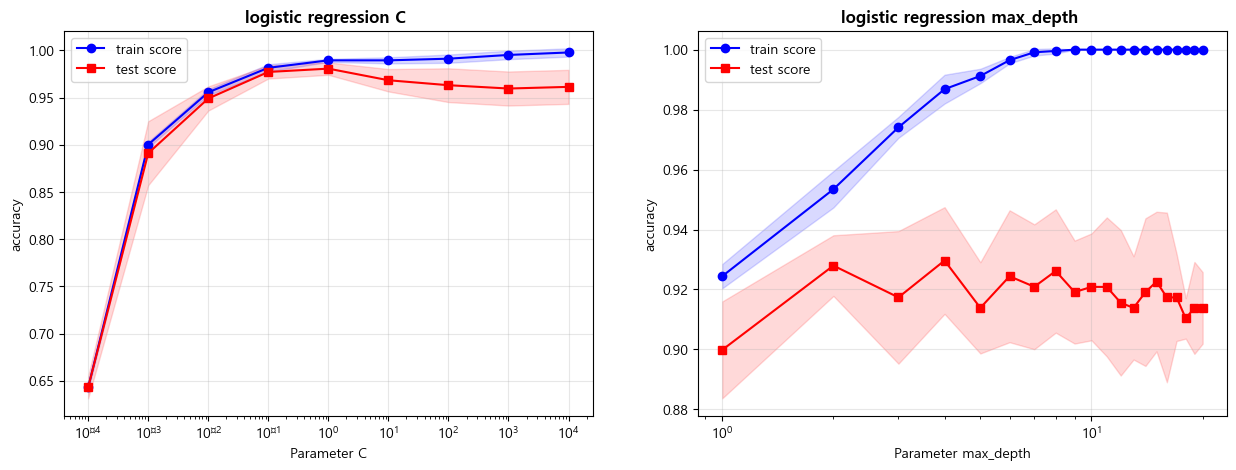

In [112]:
section5_validation_curve(X, y)